In [1]:
print("hello")

hello


In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, log_loss, roc_auc_score

In [3]:
data=pd.read_csv('../data/water_potability.csv')

In [4]:
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


# EDA

In [5]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [6]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
ph,2785.0,7.080795,1.594320,0.000000,6.093092,7.036752,8.062066,14.000000
Hardness,3276.0,196.369496,32.879761,47.432000,176.850538,196.967627,216.667456,323.124000
Solids,3276.0,22014.092526,8768.570828,320.942611,15666.690297,20927.833607,27332.762127,61227.196008
Chloramines,3276.0,7.122277,1.583085,0.352000,6.127421,7.130299,8.114887,13.127000
Sulfate,2495.0,333.775777,41.416840,129.000000,307.699498,333.073546,359.950170,481.030642
Conductivity,3276.0,426.205111,80.824064,181.483754,365.734414,421.884968,481.792305,753.342620
Organic_carbon,3276.0,14.284970,3.308162,2.200000,12.065801,14.218338,16.557652,28.300000
Trihalomethanes,3114.0,66.396293,16.175008,0.738000,55.844536,66.622485,77.337473,124.000000
Turbidity,3276.0,3.966786,0.780382,1.450000,3.439711,3.955028,4.500320,6.739000
Potability,3276.0,0.390110,0.487849,0.000000,0.000000,0.000000,1.000000,1.000000


In [7]:
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [8]:
import missingno as msno
import plotly.express as px

<Axes: >

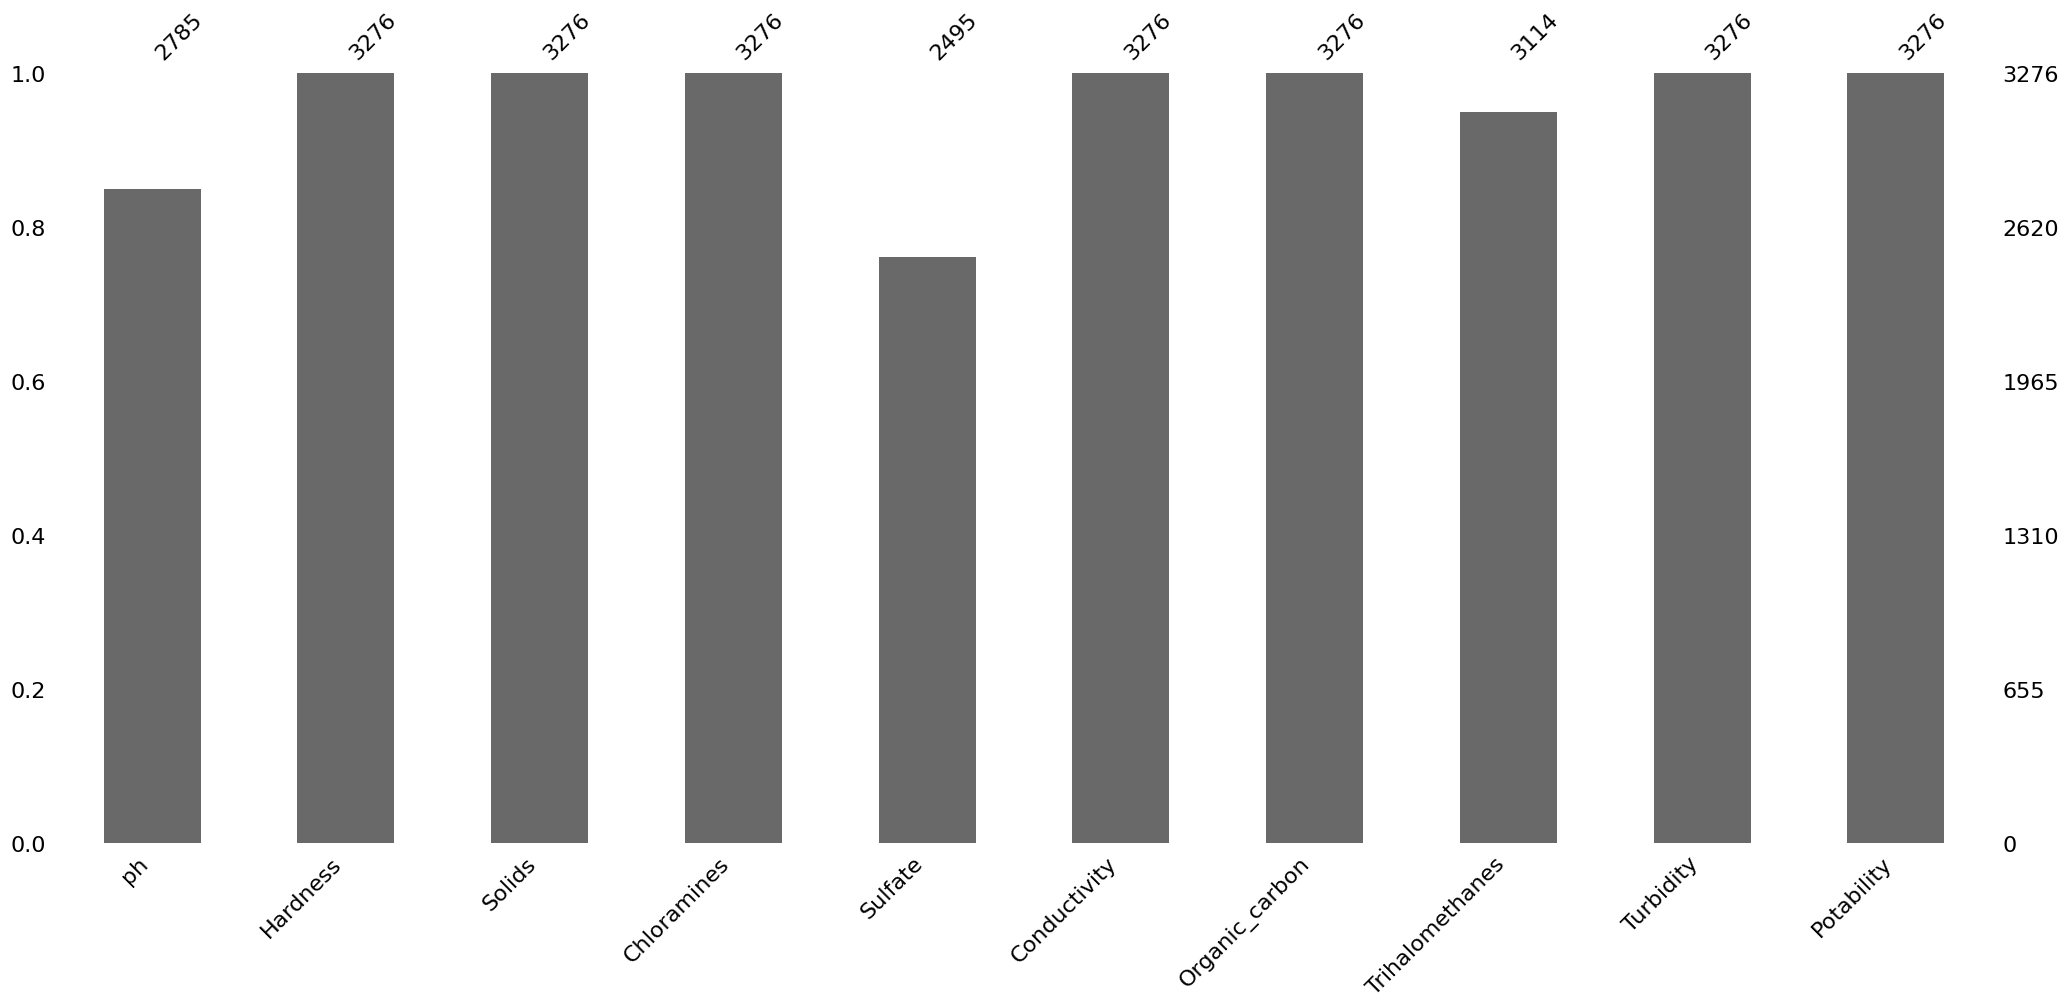

In [9]:
msno.bar(data)

In [10]:
data_null=(data.isnull().sum()/len(data))*100
data_null=data_null.to_frame()


In [11]:
data_null

,0
ph,14.987790
Hardness,0.000000
Solids,0.000000
Chloramines,0.000000
Sulfate,23.840049
Conductivity,0.000000
Organic_carbon,0.000000
Trihalomethanes,4.945055
Turbidity,0.000000
Potability,0.000000


In [12]:
print(data.nunique())

ph                 2785
Hardness           3276
Solids             3276
Chloramines        3276
Sulfate            2495
Conductivity       3276
Organic_carbon     3276
Trihalomethanes    3114
Turbidity          3276
Potability            2
dtype: int64


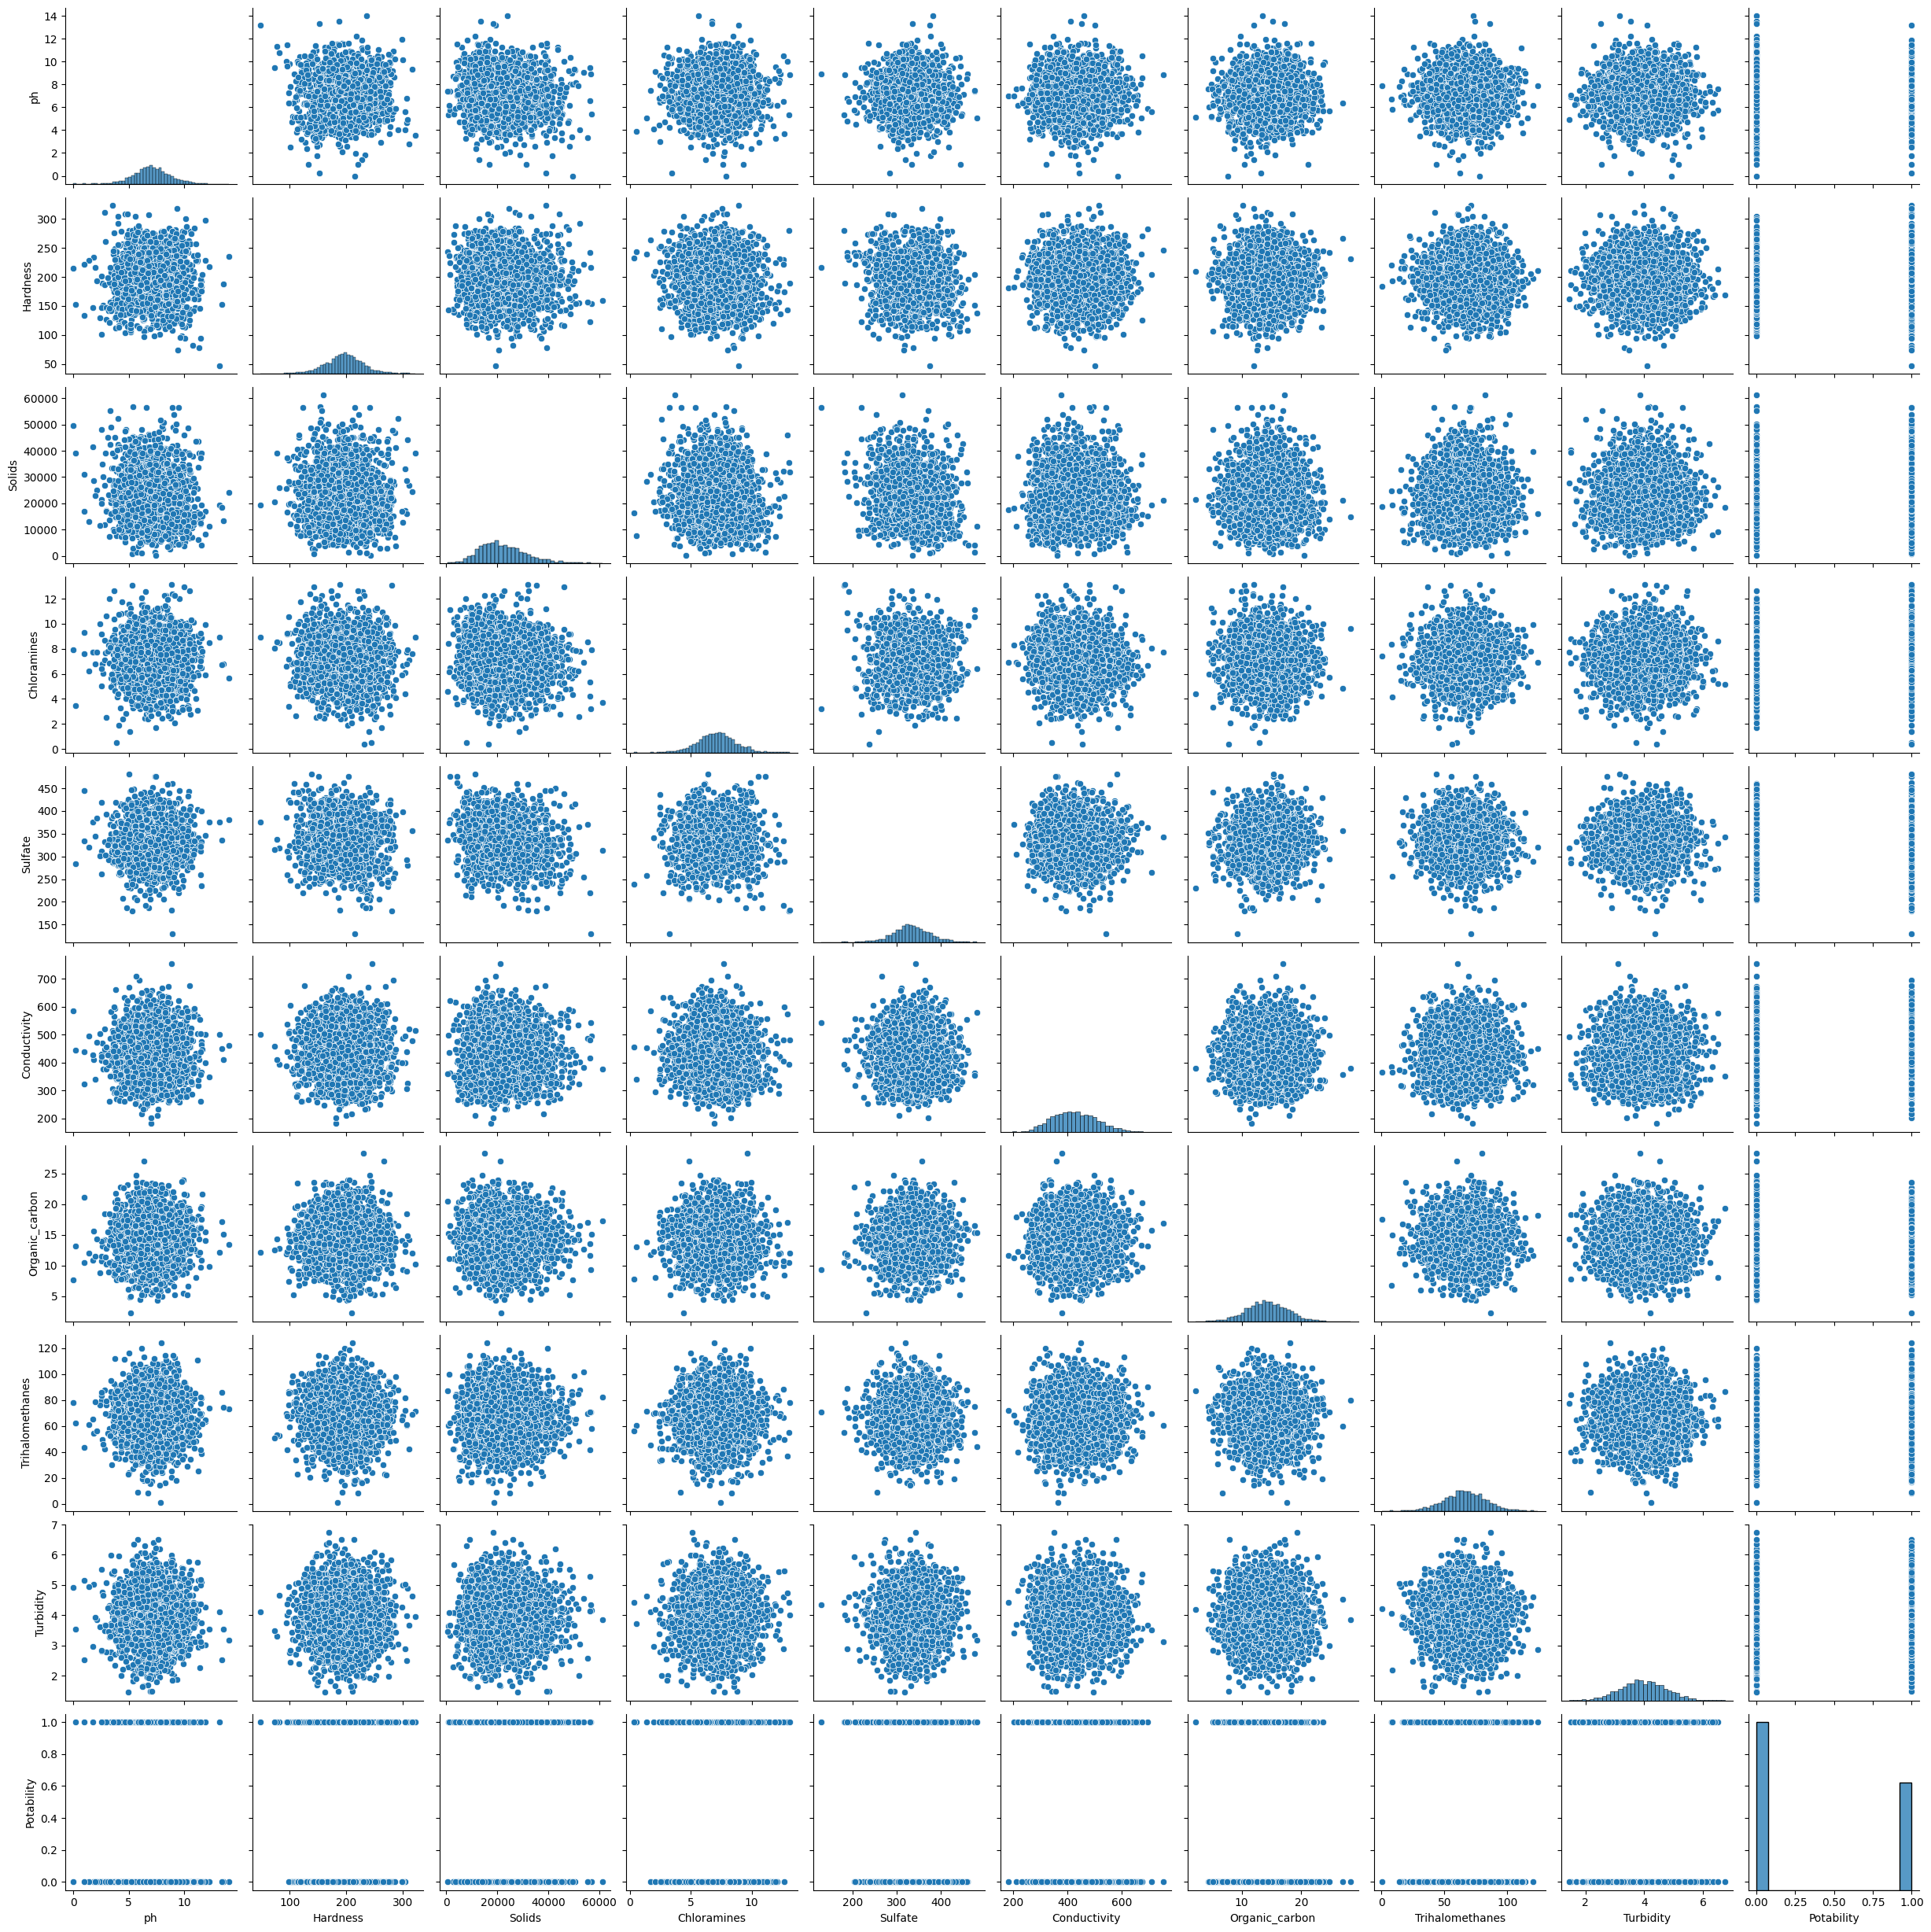

In [13]:
sns.pairplot(data)

<Axes: xlabel='Potability', ylabel='count'>

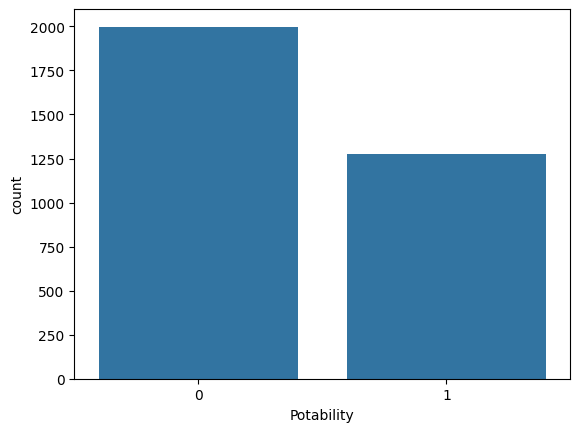

In [14]:
sns.countplot(data,x='Potability')

[]

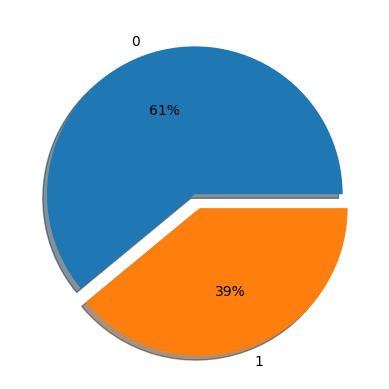

In [15]:
data['Potability'].value_counts().plot.pie(explode=(0,0.1),autopct="%.0f%%",shadow=True)
plt.plot()

* By this we can say that output value is not in equal propotional 
* imbalanced datasets, where one class significantly outnumbers the others.

In [16]:
data

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


In [17]:
x=data.iloc[:,:9]
x

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658


In [18]:
y=data['Potability']

# Balencing Data

### Random Oversampling and Undersampling:

1. Random Oversampling: This involves duplicating samples from the minority class to balance the class distribution. Be cautious with this approach, as it can lead to overfitting.

2. Random Undersampling: This involves randomly removing samples from the majority class to balance the class distribution. It may lead to a loss of valuable information.

### SMOTE (Synthetic Minority Over-sampling Technique):

* SMOTE generates synthetic samples for the minority class by interpolating between existing samples. It creates new data points by taking random linear combinations of the feature vectors of existing minority class samples.

# SMOTE

In [19]:
X=x.copy()
Y=y.copy()

In [20]:
Y

0       0
1       0
2       0
3       0
4       0
       ..
3271    1
3272    1
3273    1
3274    1
3275    1
Name: Potability, Length: 3276, dtype: int64

In [21]:
X

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075
...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658


In [22]:
X.isnull().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
dtype: int64

In [23]:
# ph_mean=X['ph'].mean()
# X['ph'].fillna(ph_mean, inplace=True)

# Sulfate_mean=X['Sulfate'].mean()
# X['Sulfate'].fillna(Sulfate_mean, inplace=True)

# Trihalomethanes_mean=X['Trihalomethanes'].mean()

# X['Trihalomethanes'].fillna(Trihalomethanes_mean, inplace=True)



X['ph'] = X['ph'].fillna(X['ph'].mean())
X['Sulfate'] = X['Sulfate'].fillna(X['Sulfate'].mean())
X['Trihalomethanes'] = X['Trihalomethanes'].fillna(X['Trihalomethanes'].mean())

In [24]:
X.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64

In [25]:
# Using smote balencing data before splitting train and test

from imblearn.over_sampling import SMOTE
smote = SMOTE(sampling_strategy='auto', random_state=42)
x_resampled, y_resampled = smote.fit_resample(X,Y)

[]

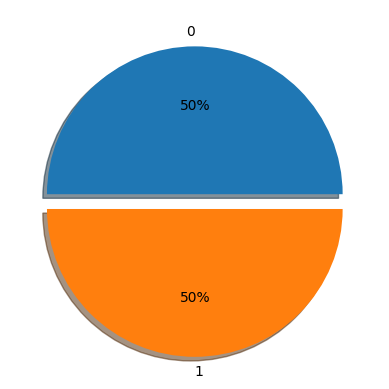

In [26]:
y_resampled.value_counts().plot.pie(explode=(0,0.1),autopct="%.0f%%",shadow=True)
plt.plot()

In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.3,random_state=42)

In [28]:
x_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2985,NaN,188.445469,28791.614416,8.040356,382.009477,422.234861,10.575690,63.235365,3.228379
1073,7.203439,168.445358,22826.484697,6.283250,271.892045,437.370863,16.410654,64.505923,6.389161
3140,NaN,242.827588,29298.074262,5.853840,340.348645,463.115174,5.426650,NaN,3.522586
2643,6.056818,211.765886,4440.277357,9.507303,NaN,316.921776,17.766397,53.541191,3.358061
2174,9.581189,223.296216,28292.780318,5.665431,NaN,398.479317,11.350768,44.574120,3.929178
...,...,...,...,...,...,...,...,...,...
1095,4.187491,208.374188,21809.709834,5.846112,327.474203,264.508083,11.235144,46.682597,4.592959
1130,7.793915,164.958947,25506.912237,7.868036,358.259200,398.460312,15.297496,NaN,4.220028
1294,6.630364,186.761088,30939.023214,7.703481,NaN,330.876083,13.815757,86.753117,3.490588
860,8.783168,218.032840,16183.586649,7.390474,334.053885,389.021616,16.354520,47.100982,4.274137


In [29]:
x_test

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
2947,NaN,183.521107,20461.252710,7.333212,333.119476,356.369022,20.179029,67.019903,4.886634
2782,6.643159,188.913541,32873.820022,6.791509,333.848842,336.561501,14.706810,67.844849,4.562198
1644,7.846058,224.058877,23264.109968,5.922367,300.402620,387.971336,13.406737,43.075186,2.487969
70,7.160467,183.089310,6743.346066,3.803036,277.599099,428.036344,9.799625,90.035374,3.884891
2045,6.615350,179.240661,26392.863612,9.309160,NaN,496.363562,12.786595,78.262369,4.453443
...,...,...,...,...,...,...,...,...,...
542,9.895889,210.654041,13189.519383,4.945128,NaN,481.136793,11.763453,49.851928,3.813429
3189,6.886513,211.454417,35018.325600,6.067597,NaN,549.997058,8.445127,27.663174,3.599756
1921,7.288737,233.977810,31617.075415,8.533888,331.838167,490.047095,12.225342,31.802024,3.531385
2839,7.243482,196.982379,29772.019247,6.497201,NaN,322.365237,14.154955,50.655001,4.763579


In [30]:
x_train.isnull().sum()

ph                 354
Hardness             0
Solids               0
Chloramines          0
Sulfate            562
Conductivity         0
Organic_carbon       0
Trihalomethanes    113
Turbidity            0
dtype: int64

## Filling null values of x_train

In [31]:
# ph_mean=x_train['ph'].mean()
# x_train['ph'].fillna(ph_mean, inplace=True)

# Sulfate_mean=x_train['Sulfate'].mean()
# x_train['Sulfate'].fillna(Sulfate_mean, inplace=True)

# Trihalomethanes_mean=x_train['Trihalomethanes'].mean()
# x_train['Trihalomethanes'].fillna(Trihalomethanes_mean, inplace=True)

x_train['ph'] = x_train['ph'].fillna(x_train['ph'].mean())
x_train['Sulfate'] = x_train['Sulfate'].fillna(x_train['Sulfate'].mean())
x_train['Trihalomethanes'] = x_train['Trihalomethanes'].fillna(
    x_train['Trihalomethanes'].mean()
)

In [32]:
x_train.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64

In [33]:
x_test.isnull().sum()

ph                 137
Hardness             0
Solids               0
Chloramines          0
Sulfate            219
Conductivity         0
Organic_carbon       0
Trihalomethanes     49
Turbidity            0
dtype: int64

In [34]:

x_test['ph'] = x_test['ph'].fillna(x_test['ph'].mean())
x_test['Sulfate'] = x_test['Sulfate'].fillna(x_test['Sulfate'].mean())
x_test['Trihalomethanes'] = x_test['Trihalomethanes'].fillna(
    x_test['Trihalomethanes'].mean()
)

In [35]:
x_test.isnull().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
dtype: int64

In [36]:
# Random Oversampling and Undersampling
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [37]:
# Random Oversampling
ros=RandomOverSampler(sampling_strategy='auto')

x_resampled,y_resampled=ros.fit_resample(x_train,y_train)

rus = RandomUnderSampler(sampling_strategy='auto')  # we can adjust the sampling strategy
x_resampled, y_resampled = rus.fit_resample(x_train, y_train)

[]

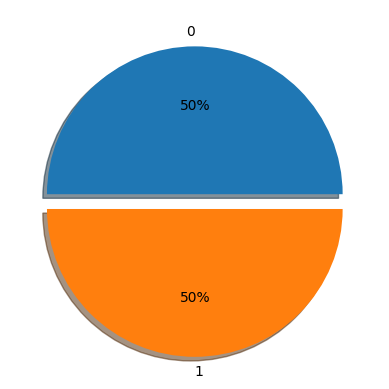

In [38]:
y_resampled.value_counts().plot.pie(explode=(0,0.1),autopct="%.0f%%",shadow=True)
plt.plot()

# scaling

In [39]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train1=scaler.fit_transform(x_train)
x_train=pd.DataFrame(x_train1,columns=x.columns)
x_test1=scaler.transform(x_test)
x_test=pd.DataFrame(x_test1,columns=x.columns)

In [40]:
x_train

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,0.000000,-0.246998,0.750536,0.587582,1.336270,-0.054682,-1.117452,-2.025150e-01,-0.938934
1,0.073242,-0.856455,0.080096,-0.527665,-1.708881,0.130717,0.656002,-1.224956e-01,3.126131
2,0.000000,1.410171,0.807459,-0.800215,0.184195,0.446057,-2.682430,-8.949963e-16,-0.560556
3,-0.710822,0.463637,-1.986388,1.518663,0.000000,-1.344653,1.068061,-8.130518e-01,-0.772151
4,1.699158,0.814997,0.694470,-0.919799,0.000000,-0.345662,-0.881878,-1.377796e+00,-0.037641
...,...,...,...,...,...,...,...,...,...
2288,-1.989076,0.360283,-0.034182,-0.805120,-0.171830,-1.986664,-0.917020,-1.245004e+00,0.816045
2289,0.477012,-0.962696,0.381358,0.478209,0.679488,-0.345895,0.317674,-8.949963e-16,0.336420
2290,-0.318629,-0.298326,0.991890,0.373764,0.000000,-1.173728,-0.132680,1.278627e+00,-0.601709
2291,1.153468,0.654608,-0.666520,0.175097,0.010122,-0.461509,0.638941,-1.218655e+00,0.406009


In [41]:
x_test

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
0,-0.034968,-0.397057,-0.185740,0.138753,-0.015718,-0.861467,1.801346,0.035834,1.193739
1,-0.309880,-0.232735,1.209348,-0.205070,0.004452,-1.104088,0.138143,0.087789,0.776483
2,0.512668,0.838238,0.129282,-0.756720,-0.920459,-0.474373,-0.256996,-1.472198,-1.891173
3,0.043858,-0.410215,-1.727539,-2.101873,-1.551060,0.016379,-1.353326,1.485343,-0.094598
4,-0.328895,-0.527494,0.480933,1.392900,0.007940,0.853314,-0.445479,0.743882,0.636615
...,...,...,...,...,...,...,...,...,...
978,1.914352,0.429756,-1.003033,-1.376980,0.007940,0.666802,-0.756448,-1.045401,-0.186505
979,-0.143473,0.454146,1.450376,-0.664542,0.007940,1.510266,-1.765006,-2.442843,-0.461308
980,0.131569,1.140494,1.068099,0.900830,-0.051151,0.775944,-0.616064,-2.182179,-0.549240
981,0.100624,0.013144,0.860727,-0.391869,0.007940,-1.277977,-0.029586,-0.994823,1.035478


# Model Comparision

## Logistic Regression

In [42]:
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
from sklearn.metrics import accuracy_score,classification_report

In [44]:
y_pred=LR.predict(x_test)

In [45]:
from sklearn.metrics import log_loss

probs = LR.predict_proba(x_test)[:, 1]
loss = log_loss(y_test, probs)

print(loss)

0.6604625366376927


In [46]:
accuracy=accuracy_score(y_test,y_pred)
accuracy

0.6286876907426246

In [47]:
report = classification_report(y_test, y_pred)
print("Classification Report:")
print(report)


print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.63      1.00      0.77       617
           1       1.00      0.00      0.01       366

    accuracy                           0.63       983
   macro avg       0.81      0.50      0.39       983
weighted avg       0.77      0.63      0.49       983

Confusion Matrix:
 [[617   0]
 [365   1]]


* Precision for class 0 is 0.63, meaning 63% of predictions for class 0 were correct.

* Recall for class 0 is 1.00, indicating that 100% of actual class 0 instances were correctly identified.

* The F1-score balances precision and recall, providing an overall measure of model performance.

* The support values show the distribution of actual classes in the test dataset.

* The accuracy of the model is 63%

## K-Nearest Neighbors (KNN)

In [48]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=2)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",2
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [49]:
y_pred_knn=knn.predict(x_test)

In [50]:
probs_knn = knn.predict_proba(x_test)[:, 1]

loss_knn = log_loss(y_test, probs_knn)

print(loss_knn)

7.470194537998027


In [51]:
accuracy=accuracy_score(y_test,y_pred_knn)
accuracy

0.6520854526958291

In [52]:
report = classification_report(y_test, y_pred_knn)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.90      0.76       617
           1       0.58      0.24      0.34       366

    accuracy                           0.65       983
   macro avg       0.62      0.57      0.55       983
weighted avg       0.63      0.65      0.61       983



* Precision for class 0 is 0.67, meaning 67% of predictions for class 0 were correct.
* Precision for class 1 is 0.58, meaning 58% of predictions for class 1 were correct.


* Recall for class 0 is 0.90, indicating that 90% of actual class 0 instances were correctly identified.
* Recall for class 1 is 0.24, indicating that 24% of actual class 1 instances were correctly identified.


* The F1-score balances precision and recall, providing an overall measure of model performance.

* The support values show the distribution of actual classes in the test dataset.

* The accuracy of the model is 65%

## Decision Trees classifier

In [53]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(criterion='gini',max_depth=5,random_state=42)

In [54]:
dtc.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [55]:
y_pred_dtc=dtc.predict(x_test)

In [56]:
probs_dt = dtc.predict_proba(x_test)[:, 1]

loss_dt = log_loss(y_test, probs_dt)

print(loss_dt)

1.2341672292246226


In [57]:
accuracy=accuracy_score(y_pred_dtc,y_test)

In [58]:
print(f"Accuracy: {accuracy}")

Accuracy: 0.6500508646998983


In [59]:
report = classification_report(y_test, y_pred_dtc)
print("Classification Report:")
print(report)

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.93      0.77       617
           1       0.60      0.18      0.28       366

    accuracy                           0.65       983
   macro avg       0.63      0.56      0.52       983
weighted avg       0.63      0.65      0.59       983



* Precision for class 0 is 0.66, meaning 66% of predictions for class 0 were correct.
* Precision for class 1 is 0.60, meaning 60% of predictions for class 1 were correct.

* Recall for class 0 is 0.93, indicating that 93% of actual class 0 instances were correctly identified.
* Recall for class 1 is 0.18, indicating that 18% of actual class 1 instances were correctly identified.

* By this we can say recall of 1 is decreasing ie percent of correctly predicting actual value is 18% 
* The accuracy of the model is 65%

## Random Forest  Classifier

In [60]:
from sklearn.ensemble import RandomForestClassifier
RF=RandomForestClassifier(n_estimators=100,random_state=42)

In [61]:
RF.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
pred_rf=RF.predict(x_test)

In [63]:
probs_rf = RF.predict_proba(x_test)[:, 1]

loss_rf = log_loss(y_test, probs_rf)

print(loss_rf)

0.6024116081794731


In [64]:
accuracy=accuracy_score(pred_rf,y_test)

In [65]:
print(f"accuracy:{accuracy}")

accuracy:0.6876907426246185


In [66]:
report2 = classification_report(y_test, pred_rf)

In [67]:
print("Classification Report:")
print(report2)

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.88      0.78       617
           1       0.65      0.36      0.46       366

    accuracy                           0.69       983
   macro avg       0.67      0.62      0.62       983
weighted avg       0.68      0.69      0.66       983



* Precision for class 0 is 0.70, meaning 70% of predictions for class 0 were correct.

* Precision for class 1 is 0.65, meaning 65% of predictions for class 1 were correct.

* Recall for class 0 is 0.88, indicating that 88% of actual class 0 instances were correctly identified.

* Recall for class 1 is 0.36, indicating that 36% of actual class 1 instances were correctly identified.

* By this we can say recall of 1 is decreasing ie percent of correctly predicting actual value is 18%

* The accuracy of the model is 69%

* From training data in those different classification methodes Randomforest classifier gave highest accuracy score and better precision and recall

# Tuning the hyperparameters of a Random Forest classifier

In [68]:
from sklearn.model_selection import GridSearchCV

In [69]:
params={'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt', 'log2']}

In [77]:
from sklearn.ensemble import RandomForestClassifier

RF2 = RandomForestClassifier(
    n_estimators=150,
    random_state=42,
    max_depth=30,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=2
)

RF2.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",30
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [78]:
pred_rf=RF2.predict(x_test)

In [79]:
accuracy=accuracy_score(pred_rf,y_test)
print(f"accuracy:{accuracy}")


accuracy:0.6805696846388606


In [80]:
report2 = classification_report(y_test, pred_rf)
print("Classification Report:")
print(report2)

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.89      0.78       617
           1       0.64      0.33      0.43       366

    accuracy                           0.68       983
   macro avg       0.66      0.61      0.61       983
weighted avg       0.67      0.68      0.65       983



In [81]:
y_test

2947    0
2782    1
1644    0
70      0
2045    1
       ..
542     0
3189    1
1921    1
2839    1
2484    0
Name: Potability, Length: 983, dtype: int64

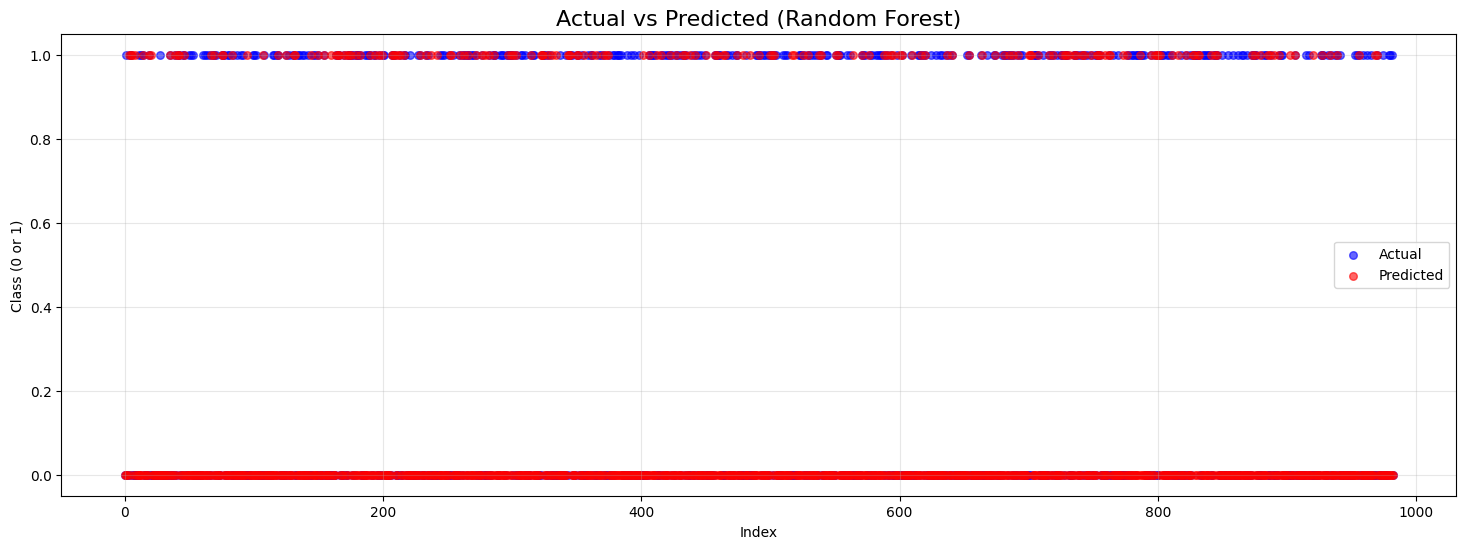

In [82]:
c = [i for i in range(len(y_test))]

plt.figure(figsize=(18,6))

plt.scatter(c, y_test, 
            color="blue", 
            alpha=0.6, 
            s=30, 
            label="Actual")


plt.scatter(c, pred_rf, 
            color="red", 
            alpha=0.6, 
            s=30, 
            label="Predicted")

plt.title("Actual vs Predicted (Random Forest)", fontsize=16)
plt.xlabel("Index")
plt.ylabel("Class (0 or 1)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [83]:
probs_rf = RF.predict_proba(x_test)[:, 1]

tuned_loss_rf = log_loss(y_test, probs_rf)

print(tuned_loss_rf)

0.6020348731978256


In [84]:
import joblib

joblib.dump(RF2, '../models/rf_model.pkl')

['../models/rf_model.pkl']